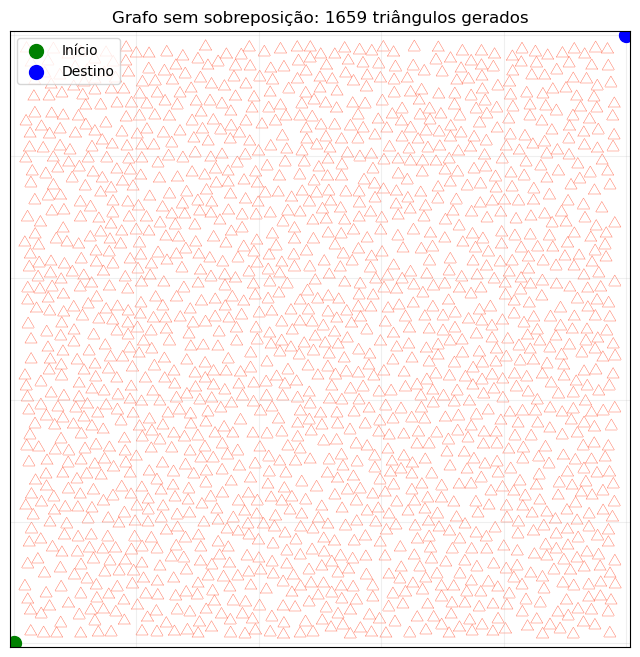

In [4]:
import networkx as nx
import math
import random
import matplotlib.pyplot as plt

def vertice_no_triangulo(vertice, v1, v2, v3):
    def sinal(p1, p2, p3):
        return (p1[0] - p3[0]) * (p2[1] - p3[1]) - (p2[0] - p3[0]) * (p1[1] - p3[1])

    orientacao_aresta1 = sinal(vertice, v1, v2)
    orientacao_aresta2 = sinal(vertice, v2, v3)
    orientacao_aresta3 = sinal(vertice, v3, v1)

    tem_negativo = (orientacao_aresta1 < 0) or (orientacao_aresta2 < 0) or (orientacao_aresta3 < 0)
    tem_positivo = (orientacao_aresta1 > 0) or (orientacao_aresta2 > 0) or (orientacao_aresta3 > 0)

    return not (tem_negativo and tem_positivo)

def triangulos_colidem(tri1, tri2):
    for vertice in tri1:
        if vertice_no_triangulo(vertice, tri2[0], tri2[1], tri2[2]):
            return True
    for vertice in tri2:
        if vertice_no_triangulo(vertice, tri1[0], tri1[1], tri1[2]):
            return True
    return False

def criar_cenario(limite_x, limite_y, qtd_obstaculos, lado_tri):
    G = nx.Graph()
    inicio = (0, 0)
    destino = (limite_x, limite_y)
    
    G.add_node(inicio)
    G.add_node(destino)
    
    h_tri = lado_tri * (math.sqrt(3) / 2)
    obstaculos_finalizados = [] 
    vertices_obs = []

    tentativas_max = qtd_obstaculos * 10
    tentativas = 0

    while len(obstaculos_finalizados) < qtd_obstaculos and tentativas < tentativas_max:
        tentativas += 1
        
        margem = 4
        rx = random.uniform(margem, LARGURA - lado_tri - margem)
        ry = random.uniform(margem, ALTURA - h_tri - margem)
        
        v1 = (round(rx, 2), round(ry, 2))
        v2 = (round(rx + lado_tri, 2), round(ry, 2))
        v3 = (round(rx + lado_tri/2, 2), round(ry + h_tri, 2))
        novo_tri = (v1, v2, v3)

        colisao = False
        for obs in obstaculos_finalizados:
            if triangulos_colidem(novo_tri, obs):
                colisao = True
                break
    
        if not colisao:
            obstaculos_finalizados.append(novo_tri)
            G.add_edges_from([(v1, v2), (v2, v3), (v3, v1)])
            vertices_obs.extend([v1, v2, v3])

    return G, inicio, destino, vertices_obs

LARGURA, ALTURA = 500, 500
QUANTIDADE = 2000 
LADO = 10

G, start, end, lista_v = criar_cenario(LARGURA, ALTURA, QUANTIDADE, LADO)

pos = {n: n for n in G.nodes()}
plt.figure(figsize=(8, 8))
nx.draw_networkx_edges(G, pos, edge_color='tomato', width=0.3)
nx.draw_networkx_nodes(G, pos, nodelist=lista_v, node_color='orange', node_size=0)
nx.draw_networkx_nodes(G, pos, nodelist=[start], node_color='green', node_size=100, label='Início')
nx.draw_networkx_nodes(G, pos, nodelist=[end], node_color='blue', node_size=100, label='Destino')

plt.title(f"Grafo sem sobreposição: {len(lista_v)//3} triângulos gerados")
plt.xlim(-3, LARGURA + 3)
plt.ylim(-3, ALTURA + 3)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()